# Prototyping Difference Gradient Analysis for MISalign 2.0

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.colors as colors

In [2]:
# %matplotlib widget
%matplotlib inline

In [3]:
from misalign.model.project import MISProjectJSON
from misalign.model.relation import MISRelationRectangular
from misalign.alignment.difference_gradient import difference_gradient_analysis,\
    metric_squared_mean,\
    metric_absolute_mean, \
    strategy_full_grid, strategy_scaled_grid


In [4]:
mis_filepath="../example/project_a/project_a-relations-calibrated.mis.json"
mis_project=MISProjectJSON.load(mis_filepath)
mis_project.find_image_paths(mis_filepath,update=True)
print(mis_project)

A misalign project with:
Images:
    image_a01.jpg
    image_a02.jpg
    image_a03.jpg
    image_a04.jpg
    image_a05.jpg
    image_a06.jpg
    image_a07.jpg
    image_a08.jpg
    image_a09.jpg
    image_a10.jpg
Relations:
    ('image_a01.jpg', 'image_a02.jpg')
    ('image_a02.jpg', 'image_a03.jpg')
    ('image_a03.jpg', 'image_a04.jpg')
    ('image_a04.jpg', 'image_a05.jpg')
    ('image_a05.jpg', 'image_a06.jpg')
    ('image_a06.jpg', 'image_a07.jpg')
    ('image_a07.jpg', 'image_a08.jpg')
    ('image_a08.jpg', 'image_a09.jpg')
    ('image_a09.jpg', 'image_a10.jpg')
Calibration:
    pixel : 600
    length : 1
    length_unit : mm
Project Path:
    ..\example\project_a\project_a-relations-calibrated.mis.json


In [5]:
mis_project.get_relations()[1].get_relation("r")

(8, -1141)

(8, -1146)


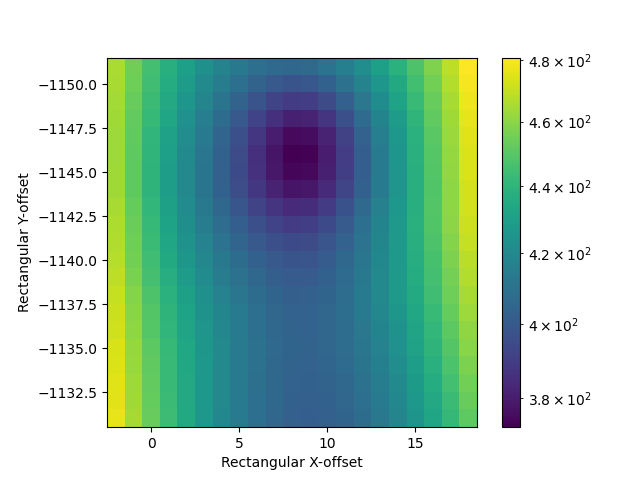

In [6]:
# Using `mis_project.get_relations()[1]` which has an ideal offset of `(8, -1146)`
# We can check strategy_max_size=50 which gives 101x101=10201 offsets.
# Not including plotting the cell takes 7.3s to run
selected_relation=mis_project.get_relations()[1]
dga_results=difference_gradient_analysis(
        image_a=mis_project.get_image(selected_relation.get_reference()[0]),
        image_b=mis_project.get_image(selected_relation.get_reference()[1]),
        relation=selected_relation,
        strategy=strategy_scaled_grid,
        # metric=metric_squared_mean,
        strategy_max_size=10,
        strategy_grid_scale=1,
        )
print(dga_results["optimized_offset"])
plt.figure()
plt.imshow(dga_results["grid_results"].T,
    norm=colors.LogNorm(vmin=np.nanmin(dga_results["grid_results"]),
                        vmax=np.nanmax(dga_results["grid_results"])),
    extent=(np.min(dga_results["grid"][0])-0.5,
            np.max(dga_results["grid"][0])+0.5,
            np.max(dga_results["grid"][1])+0.5,
            np.min(dga_results["grid"][1])-0.5,), #xmin,xmax,ymin,ymax
    )
plt.xlabel("Rectangular X-offset")
plt.ylabel("Rectangular Y-offset")
plt.colorbar()
plt.show()

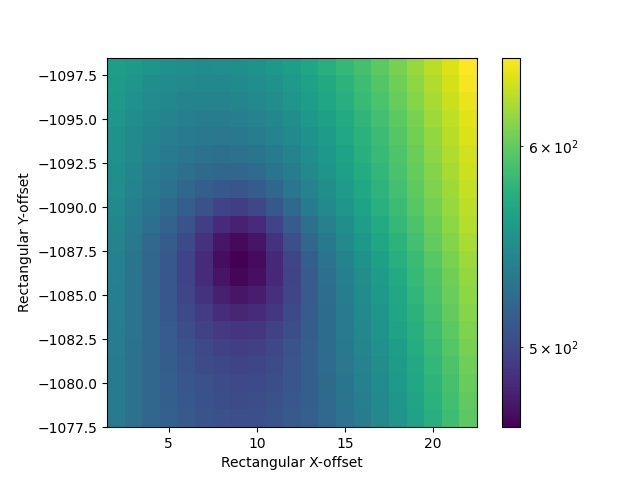

0 ('image_a01.jpg', 'image_a02.jpg') (12, -1088) -> (9, -1087)


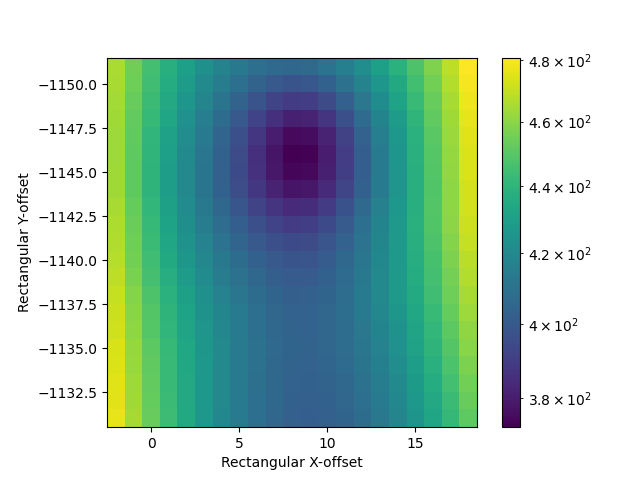

1 ('image_a02.jpg', 'image_a03.jpg') (8, -1141) -> (8, -1146)


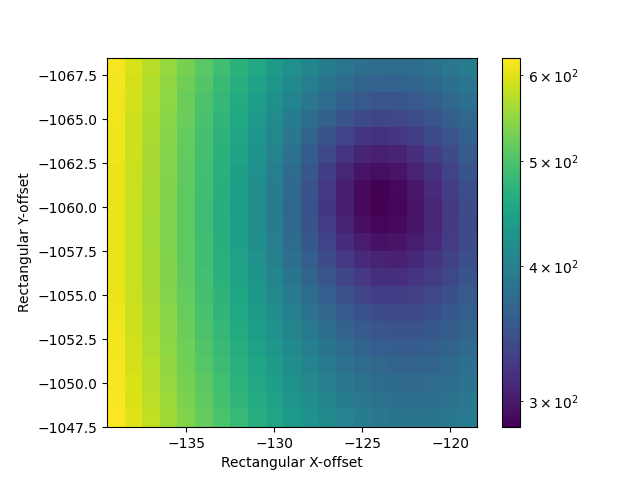

2 ('image_a03.jpg', 'image_a04.jpg') (-129, -1058) -> (-124, -1060)


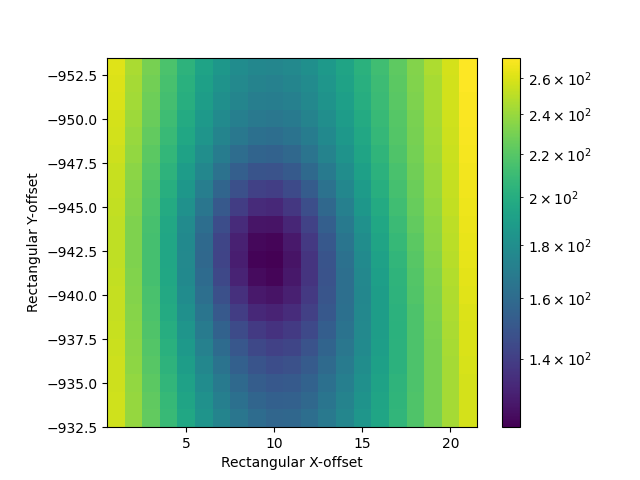

3 ('image_a04.jpg', 'image_a05.jpg') (11, -943) -> (10, -942)


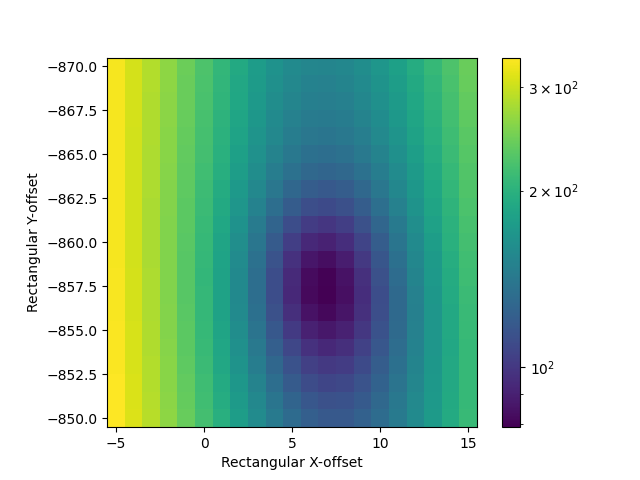

4 ('image_a05.jpg', 'image_a06.jpg') (5, -860) -> (7, -857)


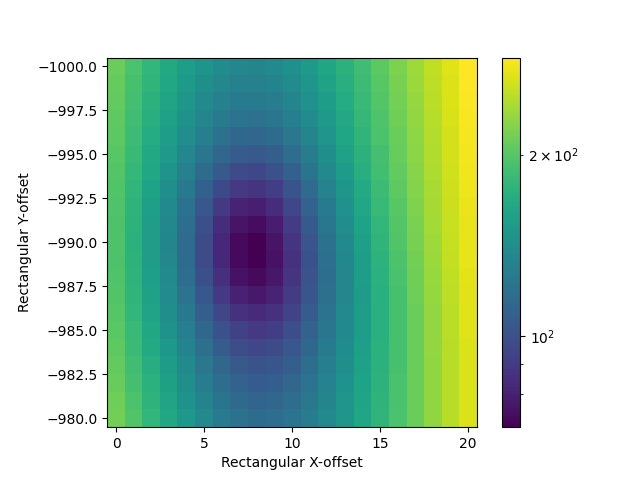

5 ('image_a06.jpg', 'image_a07.jpg') (10, -990) -> (8, -989)


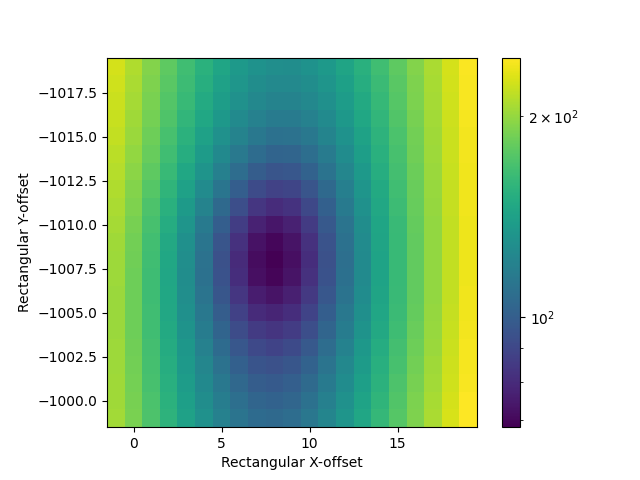

6 ('image_a07.jpg', 'image_a08.jpg') (9, -1009) -> (8, -1008)


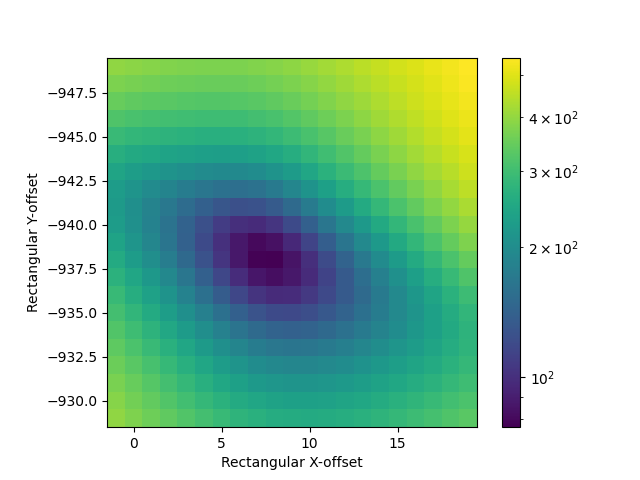

7 ('image_a08.jpg', 'image_a09.jpg') (9, -939) -> (8, -938)


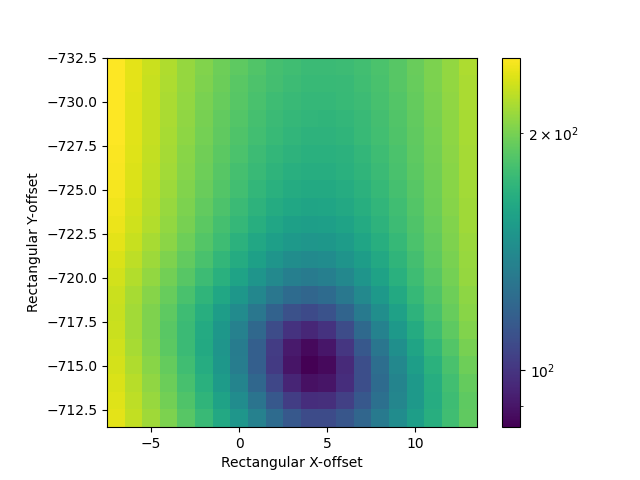

8 ('image_a09.jpg', 'image_a10.jpg') (3, -722) -> (4, -715)


In [7]:
for i,relation in enumerate(mis_project.get_relations()):
    dga_results=difference_gradient_analysis(
            image_a=mis_project.get_image(relation.get_reference()[0]),
            image_b=mis_project.get_image(relation.get_reference()[1]),
            relation=relation,
            strategy=strategy_full_grid,
            metric=metric_squared_mean,
            strategy_max_size=10,
            )
    plt.figure()
    plt.imshow(dga_results["grid_results"].T,
        norm=colors.LogNorm(vmin=np.nanmin(dga_results["grid_results"]),
                            vmax=np.nanmax(dga_results["grid_results"])),
        extent=(np.min(dga_results["grid"][0])-0.5,
                np.max(dga_results["grid"][0])+0.5,
                np.max(dga_results["grid"][1])+0.5,
                np.min(dga_results["grid"][1])-0.5,), #xmin,xmax,ymin,ymax
        )
    plt.xlabel("Rectangular X-offset")
    plt.ylabel("Rectangular Y-offset")
    plt.colorbar()
    plt.show()
    mis_project.set_relation(i,MISRelationRectangular(image_pair=relation.get_reference(),
                                                                                rectangular=dga_results["optimized_offset"],
                                                                                note="Alignment with DGA"))
    print(i,relation.get_reference(),relation.get_relation('r'),"->",dga_results["optimized_offset"])

In [8]:
mis_filepath="../example/project_a/project_a-dga_relations-calibrated.mis.json"
mis_project.save(mis_filepath)